# Exploratory Data Analysis

Este notebook analiza el dataset procesado de menopause transition usando:

- `data/processed/datos_limpios.csv`
- `data/clasificacion_variables_ml - clasificacion_variables_ml.csv`

The goal is to review data quality, the `STATUS5` target distribution,
variables by clinical/ML type, missing values, class-level patterns, and
exploratory associations useful for modeling.


## 1. Configuracion y carga reproducible


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
RANDOM_STATE = 42


def find_project_root(start: Path | None = None) -> Path:
    # Works both from notebooks/ and from the project root.
    candidates = []
    if start is not None:
        candidates.append(start.resolve())
    try:
        candidates.append(Path(__file__).resolve())
    except NameError:
        pass
    candidates.append(Path.cwd().resolve())

    for candidate in candidates:
        for parent in [candidate, *candidate.parents]:
            if (parent / "data" / "processed" / "datos_limpios.csv").exists():
                return parent
    raise FileNotFoundError(
        "Could not find data/processed/datos_limpios.csv from the current directory."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "datos_limpios.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "clasificacion_variables_ml - clasificacion_variables_ml.csv"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
TARGET = "STATUS5"

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Datos: {DATA_PATH}")
print(f"Metadata: {METADATA_PATH}")
print(f"Model metrics: {METRICS_DIR}")

In [2]:
def load_metadata(path: Path) -> pd.DataFrame:
    # Read the variable classification file and keep only useful columns.
    if not path.exists():
        raise FileNotFoundError(f"Metadata file does not exist: {path}")

    meta = pd.read_csv(path, dtype=str, keep_default_na=False)
    meta = meta.loc[:, ~meta.columns.str.startswith("Unnamed")]
    expected = ["variable", "descripcion", "tipo_variable", "razon_clinica", "recomendacion_ml"]
    missing = [col for col in expected if col not in meta.columns]
    if missing:
        raise ValueError(f"Missing columns in metadata: {missing}")

    for col in expected:
        meta[col] = meta[col].astype(str).str.strip()

    # Algunas filas pueden venir desplazadas si la descripcion contiene comas sin comillas.
    valid_types = {"binaria", "ordinal", "nominal", "continua", "target"}
    shifted = ~meta["tipo_variable"].str.lower().isin(valid_types)
    meta.loc[shifted, "descripcion"] = (
        meta.loc[shifted, "descripcion"].str.cat(meta.loc[shifted, "tipo_variable"], sep=", ")
    )
    meta.loc[shifted, "tipo_variable"] = meta.loc[shifted, "razon_clinica"]
    meta.loc[shifted, "razon_clinica"] = meta.loc[shifted, "recomendacion_ml"]
    meta.loc[shifted, "recomendacion_ml"] = ""

    return meta


df = pd.read_csv(DATA_PATH)
metadata = load_metadata(METADATA_PATH)

if TARGET not in df.columns:
    raise ValueError(f"Expected target variable was not found: {TARGET}")

print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Metadata: {metadata.shape[0]:,} documented variables")
display(df.head())
display(metadata.head(10))


Dataset: 2,204 filas x 43 columnas
Metadatos: 42 variables documentadas


,ANEMIA5,DIABETE5,HIGHBP5,HBCHOLE5,MIGRAIN5,OSTEOAR5,THYROID5,PELVCPN5,FIBRUTR5,NERVES5,SMOKERE5,ENERGY5,WORNOUT5,TIRED5,STIFF5,ACHES5,COLDSWE5,NITESWE5,VAGINDR5,FEELBLU5,DIZZY5,IRRITAB5,NRVOUS5,FORGET5,MOODCHG5,HARTRAC5,FEARFULA5,HDACHE5,HOTFLAS5,BRSTPAI5,TRBLSLE5,WAKEUP5,WAKEARL5,SLEEPQL5,GETUPUR5,DESIRSE5,ENGAGSE5,PELVIC5,LUBRICN5,WEIGHT5,BMI5,STATUS5,RACE
0,1,1.0,1,1.0,1,1.0,1.0,1,1,0.0,1.0,3.0,5.0,5.0,4.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,4.0,5.0,52.4,20.165139,2,4
1,1,1.0,1,1.0,1,1.0,1.0,1,2,0.0,1.0,3.0,4.0,5.0,2.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,5.0,2.0,3.0,2.0,1.0,5.0,1.0,1.0,5.0,5.0,1.0,5.0,2.0,2.0,6.0,1.0,68.8,26.054438,2,1
2,1,1.0,2,1.0,1,1.0,1.0,1,1,0.0,1.0,2.0,5.0,5.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,2.0,2.0,5.0,1.0,1.0,-1.0,-1.0,70.0,31.319560,2,3
3,1,1.0,1,1.0,1,1.0,2.0,1,1,0.0,1.0,3.0,5.0,5.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,2.0,2.0,4.0,5.0,54.0,22.828695,2,2
4,1,1.0,1,1.0,1,1.0,1.0,1,1,0.0,1.0,5.0,4.0,4.0,1.0,2.0,1.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,2.0,4.0,1.0,1.0,3.0,2.0,2.0,1.0,2.0,2.0,3.0,5.0,85.0,28.598576,2,4


,variable,descripcion,tipo_variable,razon_clinica,recomendacion_ml
0,ANEMIA5,Historial o presencia de anemia diagnosticada ...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
1,DIABETE5,Historial o presencia de diabetes diagnosticad...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
2,HIGHBP5,Historial o presencia de hipertensiÃƒÆ’Ã‚Â³n arteria...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
3,HBCHOLE5,Historial o presencia de colesterol alto diagn...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
4,MIGRAIN5,Historial o presencia de migraÃƒÆ’Ã‚Â±as diagnostica...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
5,OSTEOAR5,Historial o presencia de osteoartritis diagnos...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
6,THYROID5,Historial o presencia de enfermedad de la tiro...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
7,FIBRUTR5,Historial o presencia de fibromas uterinos dia...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica
8,NERVES5,Nivel de nerviosismo o estrÃƒÆ’Ã‚Â©s auto-reportado ...,ordinal,Escala Likert cuantitativa que evalÃƒÆ’Ã‚Âºa la frec...,mantener numÃƒÆ’Ã‚Â©rica
9,SMOKERE5,Estado o historial de consumo de tabaco (Fumad...,nominal,Variable categÃƒÆ’Ã‚Â³rica de clasificaciÃƒÆ’Ã‚Â³n de hÃƒÆ’Ã‚Â¡b...,mantener numerica codificada


## 1.b Special Codes

This explicitly verifies that `-1` remains available as a valid category, while `-9`, `-8`, and `-7` continue to be treated as missing values.

In [3]:
special_codes = [-9, -8, -7, -1]
special_code_counts = []
for col in df.columns:
    for code in special_codes:
        n = int((df[col] == code).sum())
        if n > 0:
            special_code_counts.append({"variable": col, "codigo": code, "n": n})

special_code_counts = pd.DataFrame(special_code_counts)
print("Codes -9, -8, and -7 are interpreted as missing; -1 is preserved as a valid category.")
if special_code_counts.empty:
    print("No remaining special codes were found in the cleaned dataset.")
else:
    display(special_code_counts.sort_values(["codigo", "variable"]))


Codigos -9, -8 y -7 se interpretan como missing; -1 se conserva como categoria valida.


,variable,codigo,n
0,ANEMIA5,-1,58
5,BRSTPAI5,-1,17
4,FIBRUTR5,-1,58
1,HBCHOLE5,-1,58
7,LUBRICN5,-1,614
2,MIGRAIN5,-1,58
3,PELVCPN5,-1,58
6,PELVIC5,-1,614


## 2. Consistency Between Data and Metadata


In [4]:
data_cols = set(df.columns)
meta_cols = set(metadata["variable"])

columns_without_metadata = sorted(data_cols - meta_cols)
metadata_without_data = sorted(meta_cols - data_cols)
duplicated_metadata = metadata.loc[metadata["variable"].duplicated(keep=False), "variable"].tolist()

consistency = pd.DataFrame(
    {
        "chequeo": [
            "columns_in_data",
            "variables_in_metadata",
            "columns_without_metadata",
            "metadata_without_column",
            "duplicated_metadata_variables",
        ],
        "valor": [
            len(data_cols),
            len(meta_cols),
            len(columns_without_metadata),
            len(metadata_without_data),
            len(duplicated_metadata),
        ],
    }
)
display(consistency)

if columns_without_metadata:
    print("Columns without metadata:", columns_without_metadata)
if metadata_without_data:
    print("Metadata without data column:", metadata_without_data)
if duplicated_metadata:
    print("Duplicated metadata variables:", duplicated_metadata)


,chequeo,valor
0,columnas_en_datos,43
1,variables_en_metadatos,42
2,columnas_sin_metadatos,1
3,metadatos_sin_columna,0
4,variables_duplicadas_en_metadatos,0


Columnas sin metadatos: ['PELVCPN5']


In [5]:
variable_catalog = (
    pd.DataFrame({"variable": df.columns})
    .merge(metadata, on="variable", how="left")
    .assign(
        dtype=lambda x: x["variable"].map(df.dtypes.astype(str)),
        missing_pct=lambda x: x["variable"].map(df.isna().mean()).round(4),
        unique_values=lambda x: x["variable"].map(df.nunique(dropna=True)),
    )
)

display(variable_catalog.sort_values(["tipo_variable", "variable"]))


,variable,descripcion,tipo_variable,razon_clinica,recomendacion_ml,dtype,missing_pct,unique_values
0,ANEMIA5,Historial o presencia de anemia diagnosticada ...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,int64,0.0000,3
1,DIABETE5,Historial o presencia de diabetes diagnosticad...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.0005,2
8,FIBRUTR5,Historial o presencia de fibromas uterinos dia...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,int64,0.0000,3
3,HBCHOLE5,Historial o presencia de colesterol alto diagn...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.0005,3
2,HIGHBP5,Historial o presencia de hipertensiÃƒÆ’Ã‚Â³n arteria...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,int64,0.0000,2
4,MIGRAIN5,Historial o presencia de migraÃƒÆ’Ã‚Â±as diagnostica...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,int64,0.0000,3
5,OSTEOAR5,Historial o presencia de osteoartritis diagnos...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.0018,2
6,THYROID5,Historial o presencia de enfermedad de la tiro...,binaria,Variable dicotÃƒÆ’Ã‚Â³mica (SÃƒÆ’Ã‚Â­/No) que representa u...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.0014,2
40,BMI5,ÃƒÆ’Ã‚Ândice de Masa Corporal calculado (IMC),continua,Indicador numÃƒÆ’Ã‚Â©rico continuo derivado de la re...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.1248,1910
39,WEIGHT5,Peso corporal medido en kilogramos,continua,Variable fÃƒÆ’Ã‚Â­sica mÃƒÆ’Ã‚Â©trica continua de naturale...,mantener numÃƒÆ’Ã‚Â©rica,float64,0.0821,701


## 3. General Structure and Data Quality


,tipo_variable,dtype,n_variables,missing_pct_mean
0,binaria,float64,4,0.001050
1,binaria,int64,4,0.000000
2,continua,float64,2,0.103450
3,nominal,float64,1,0.049500
4,nominal,int64,2,0.000000
5,ordinal,float64,29,0.076393
6,NaN,int64,1,0.000000


,variable,tipo_variable,missing_pct,unique_values
40,BMI5,continua,0.1248,1910
35,DESIRSE5,ordinal,0.1116,5
36,ENGAGSE5,ordinal,0.1007,2
37,PELVIC5,ordinal,0.0962,7
38,LUBRICN5,ordinal,0.0957,7
9,NERVES5,ordinal,0.0826,29
16,COLDSWE5,ordinal,0.0826,5
39,WEIGHT5,continua,0.0821,701
27,HDACHE5,ordinal,0.0817,5
12,WORNOUT5,ordinal,0.0812,6


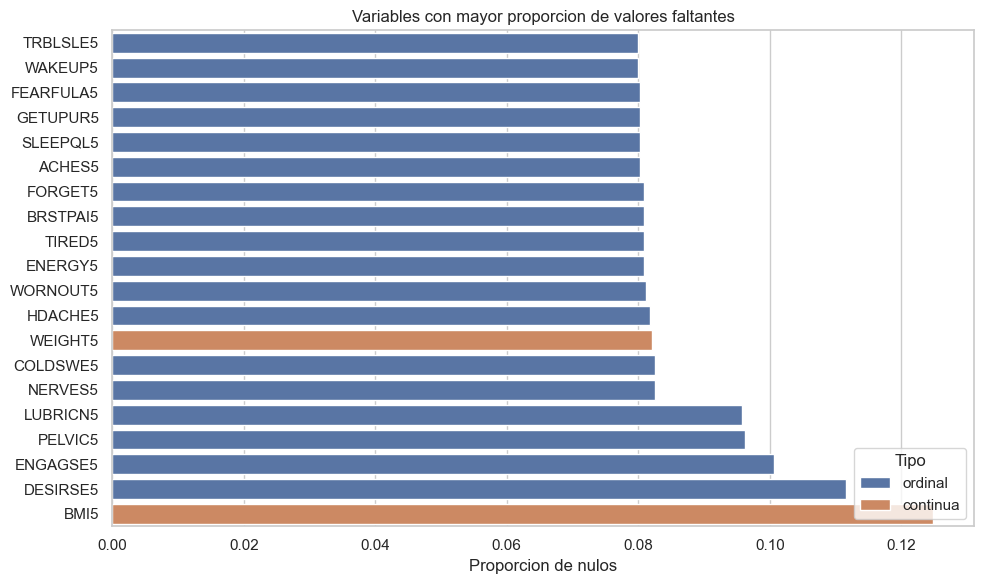

In [6]:
type_summary = (
    variable_catalog
    .groupby(["tipo_variable", "dtype"], dropna=False)
    .agg(n_variables=("variable", "count"), missing_pct_mean=("missing_pct", "mean"))
    .reset_index()
    .sort_values(["tipo_variable", "dtype"])
)
display(type_summary)

missing_summary = (
    variable_catalog[["variable", "tipo_variable", "missing_pct", "unique_values"]]
    .sort_values("missing_pct", ascending=False)
)
display(missing_summary.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing_summary.query("missing_pct > 0").head(20).sort_values("missing_pct")
if top_missing.empty:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
    ax.set_axis_off()
else:
    sns.barplot(data=top_missing, x="missing_pct", y="variable", hue="tipo_variable", dodge=False, ax=ax)
    ax.set_xlabel("Missing-value proportion")
    ax.set_ylabel("")
    ax.set_title("Variables with highest missing-value proportion")
    ax.legend(title="Tipo", loc="lower right")
plt.tight_layout()
plt.show()


In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
descriptive = df[numeric_cols].describe().T
descriptive["missing_pct"] = df[numeric_cols].isna().mean()
descriptive["unique_values"] = df[numeric_cols].nunique(dropna=True)
display(descriptive.sort_values("missing_pct", ascending=False))


,count,mean,std,min,25%,50%,75%,max,missing_pct,unique_values
BMI5,1929.0,28.981545,7.355963,15.758883,23.471074,27.444865,32.861374,65.4262,0.124773,1910
DESIRSE5,1958.0,2.551583,1.017047,1.000000,2.000000,2.000000,3.000000,5.0000,0.111615,5
ENGAGSE5,1982.0,1.697275,0.459553,1.000000,1.000000,2.000000,2.000000,2.0000,0.100726,2
PELVIC5,1992.0,2.650602,2.580188,-1.000000,-1.000000,4.000000,5.000000,6.0000,0.096189,7
LUBRICN5,1993.0,2.581535,2.646226,-1.000000,-1.000000,4.000000,5.000000,6.0000,0.095735,7
NERVES5,2022.0,1.420870,5.746623,0.000000,0.000000,0.000000,0.000000,60.0000,0.082577,29
COLDSWE5,2022.0,1.205242,0.630663,1.000000,1.000000,1.000000,1.000000,5.0000,0.082577,5
WEIGHT5,2023.0,76.222419,20.932650,38.400000,60.900000,72.000000,87.000000,209.9000,0.082123,701
HDACHE5,2024.0,1.774209,0.827067,1.000000,1.000000,2.000000,2.000000,5.0000,0.081670,5
WORNOUT5,2025.0,4.184198,1.135202,1.000000,4.000000,4.000000,5.000000,6.0000,0.081216,6


## 4. `STATUS5` Target Distribution


,STATUS5,n,pct
0,2,808,0.366606
1,3,278,0.126134
2,4,997,0.452359
3,5,121,0.054900


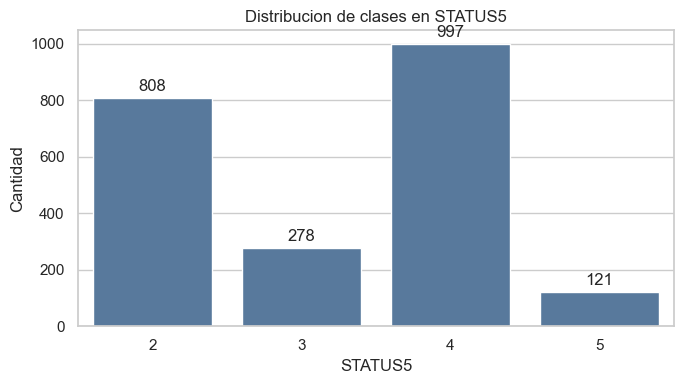

In [8]:
target_counts = (
    df[TARGET]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(TARGET)
    .reset_index(name="n")
)
target_counts["pct"] = target_counts["n"] / len(df)
display(target_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=target_counts, x=TARGET, y="n", color="#4C78A8", ax=ax)
ax.set_title("Class distribution in STATUS5")
ax.set_xlabel("STATUS5")
ax.set_ylabel("Cantidad")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()


## 5. Continuous Variables: Distribution by Class


WEIGHT5                         BMI5                       
          count    mean median     std count    mean  median    std
STATUS5                                                            
2           748  75.980  72.05  20.398   715  29.042  27.580  7.244
3           255  79.620  76.90  23.646   241  30.138  28.613  8.483
4           907  75.224  70.80  20.676   866  28.564  26.978  7.132
5           113  78.173  73.60  19.255   107  29.350  26.937  6.937

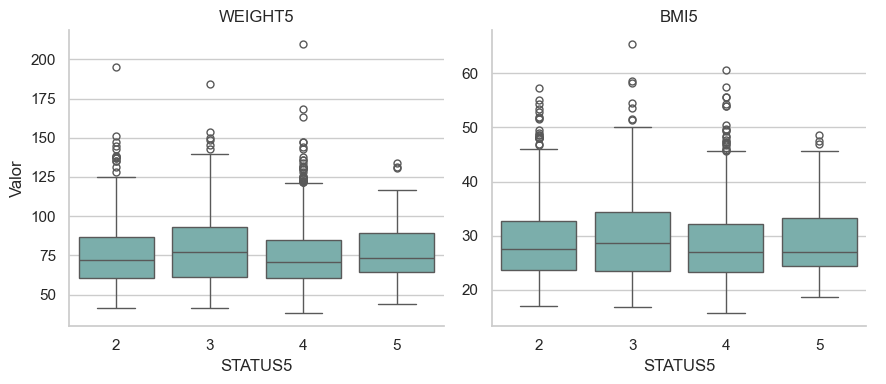

In [9]:
continuous_vars = (
    metadata.loc[metadata["tipo_variable"].str.lower().eq("continua"), "variable"]
    .pipe(lambda s: [col for col in s if col in df.columns and col != TARGET])
)

if continuous_vars:
    display(df.groupby(TARGET)[continuous_vars].agg(["count", "mean", "median", "std"]).round(3))

    melted = df[[TARGET, *continuous_vars]].melt(id_vars=TARGET, var_name="variable", value_name="valor")
    g = sns.catplot(
        data=melted,
        x=TARGET,
        y="valor",
        col="variable",
        kind="box",
        sharey=False,
        height=4,
        aspect=1.1,
        color="#72B7B2",
    )
    g.set_axis_labels("STATUS5", "Valor")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()
else:
    print("No continuous variables were identified in the metadata.")


## 6. Categorical and Ordinal Variables by Class


,variable,tipo_variable,unique_values,missing_pct
1,DIABETE5,binaria,2,0.0005
2,HIGHBP5,binaria,2,0.0000
5,OSTEOAR5,binaria,2,0.0018
6,THYROID5,binaria,2,0.0014
0,ANEMIA5,binaria,3,0.0000
8,FIBRUTR5,binaria,3,0.0000
3,HBCHOLE5,binaria,3,0.0005
4,MIGRAIN5,binaria,3,0.0000
10,SMOKERE5,nominal,2,0.0495
42,RACE,nominal,5,0.0000


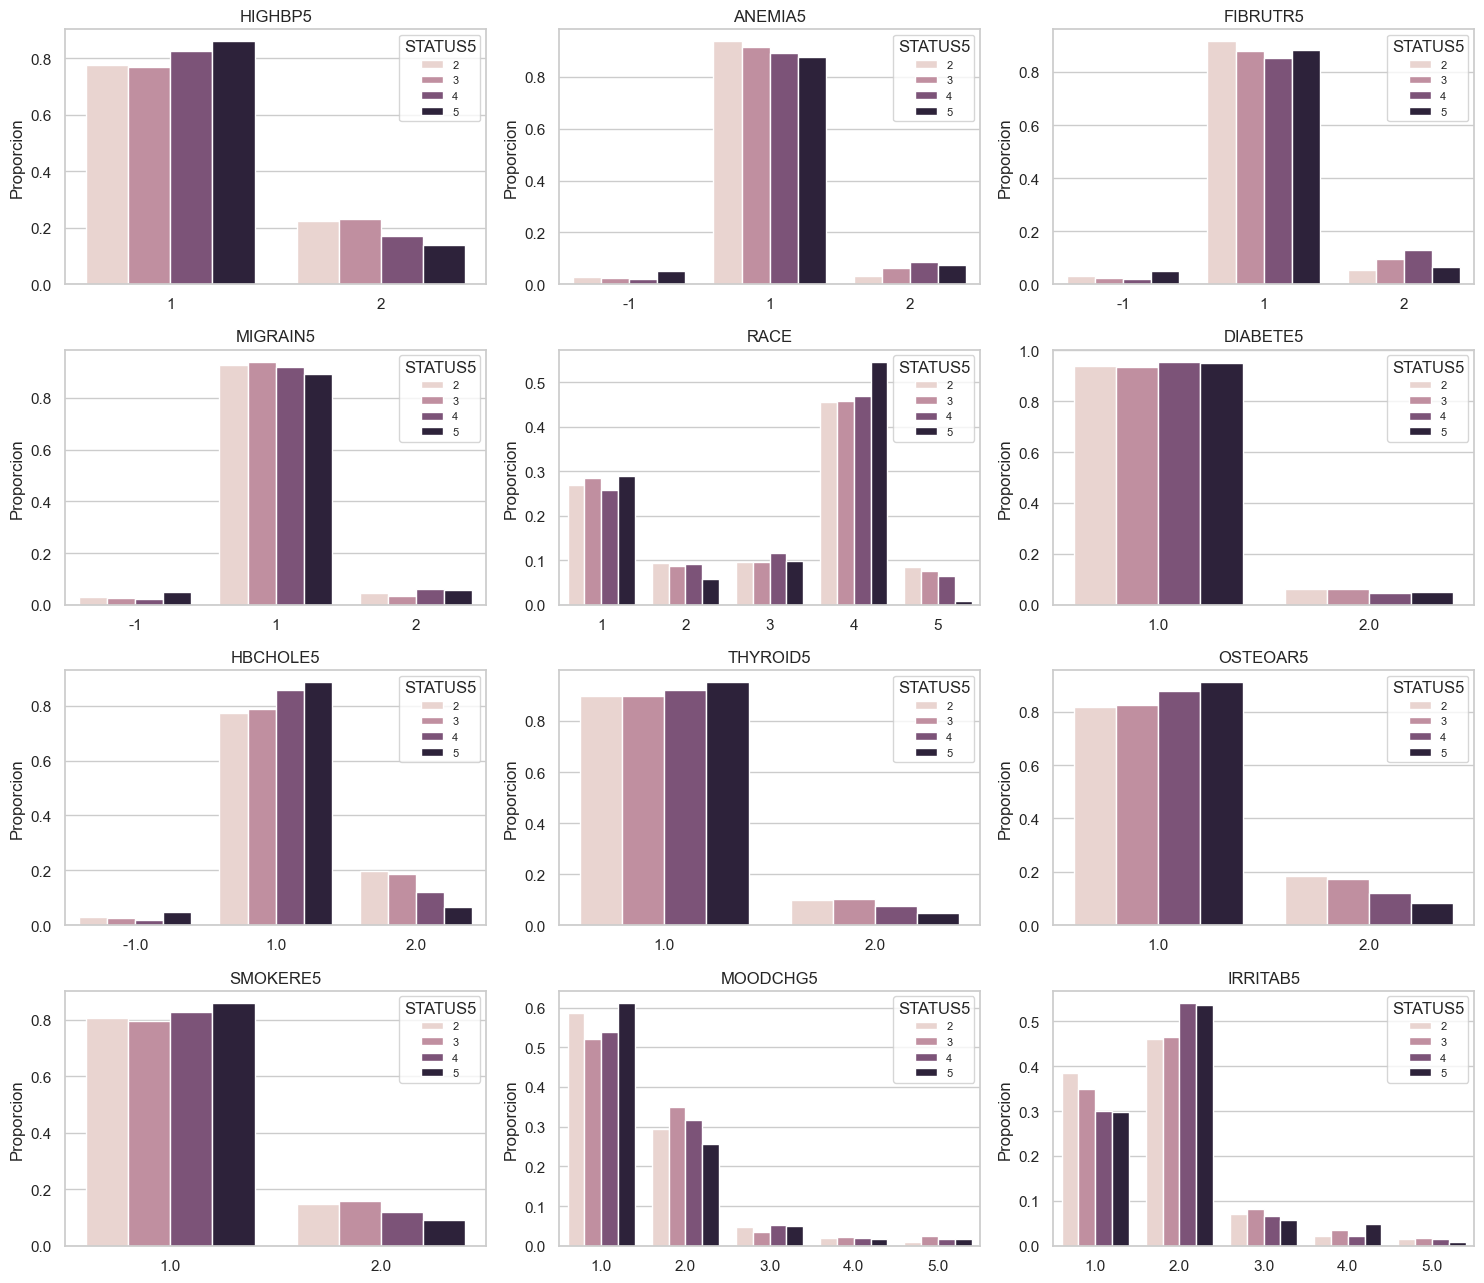

In [10]:
categorical_like = (
    metadata.loc[
        metadata["tipo_variable"].str.lower().isin(["binaria", "ordinal", "nominal"]),
        "variable",
    ]
    .pipe(lambda s: [col for col in s if col in df.columns and col != TARGET])
)

cardinality = (
    variable_catalog[variable_catalog["variable"].isin(categorical_like)]
    .sort_values(["tipo_variable", "unique_values", "variable"])
    [["variable", "tipo_variable", "unique_values", "missing_pct"]]
)
display(cardinality)

selected = cardinality.sort_values(["missing_pct", "unique_values"]).head(12)["variable"].tolist()
if selected:
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 13))
    axes = axes.ravel()
    for ax, col in zip(axes, selected):
        counts = (
            df.groupby([TARGET, col], dropna=False)
            .size()
            .reset_index(name="n")
        )
        counts["proporcion"] = counts["n"] / counts.groupby(TARGET)["n"].transform("sum")
        prop = counts
        sns.barplot(data=prop, x=col, y="proporcion", hue=TARGET, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Proporcion")
        ax.legend(title=TARGET, fontsize=8)
    for ax in axes[len(selected):]:
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


## 7. Exploratory Association with `STATUS5`


In [ ]:
analysis_df = df.dropna(subset=[TARGET]).copy()
y = analysis_df[TARGET].astype(int)
feature_cols = [col for col in analysis_df.columns if col != TARGET]

# The final model uses numeric variables and SimpleImputer(strategy="median").
# To keep the EDA consistent, exploratory imputation replicates that decision.
X = analysis_df[feature_cols].apply(pd.to_numeric, errors="coerce")
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols, index=X.index)

discrete_mask = [
    col in categorical_like or X_imp[col].nunique(dropna=True) <= 10
    for col in feature_cols
]

mi = mutual_info_classif(
    X_imp,
    y,
    discrete_features=discrete_mask,
    random_state=RANDOM_STATE,
)
mi_table = (
    pd.DataFrame({"variable": feature_cols, "mutual_info": mi})
    .merge(variable_catalog[["variable", "tipo_variable", "descripcion"]], on="variable", how="left")
    .sort_values("mutual_info", ascending=False)
)
display(mi_table.head(20))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=mi_table.head(20), x="mutual_info", y="variable", hue="tipo_variable", dodge=False, ax=ax)
ax.set_title("Top variables by mutual information with STATUS5")
ax.set_xlabel("Informacion mutua")
ax.set_ylabel("")
ax.legend(title="Tipo")
plt.tight_layout()
plt.show()

In [12]:
association_rows = []
for col in feature_cols:
    tipo = variable_catalog.loc[variable_catalog["variable"].eq(col), "tipo_variable"].iloc[0]
    values = analysis_df[[TARGET, col]].dropna()
    if values[col].nunique() < 2:
        continue

    if str(tipo).lower() in {"binaria", "ordinal", "nominal"} or values[col].nunique() <= 10:
        table = pd.crosstab(values[TARGET], values[col])
        if table.shape[0] > 1 and table.shape[1] > 1:
            chi2, p_value, _, _ = chi2_contingency(table)
            association_rows.append(
                {
                    "variable": col,
                    "tipo_variable": tipo,
                    "test": "chi2",
                    "statistic": chi2,
                    "p_value": p_value,
                }
            )
    else:
        groups = [group[col].values for _, group in values.groupby(TARGET) if len(group) > 1]
        if len(groups) > 1:
            stat, p_value = kruskal(*groups)
            association_rows.append(
                {
                    "variable": col,
                    "tipo_variable": tipo,
                    "test": "kruskal",
                    "statistic": stat,
                    "p_value": p_value,
                }
            )

association_table = (
    pd.DataFrame(association_rows)
    .sort_values("p_value")
    .merge(variable_catalog[["variable", "descripcion"]], on="variable", how="left")
)
display(association_table.head(25))


,variable,tipo_variable,test,statistic,p_value,descripcion
0,HOTFLAS5,ordinal,chi2,120.749458,4.380718e-20,Frecuencia o severidad de sofocos (bochornos) ...
1,DESIRSE5,ordinal,chi2,86.079247,2.821667e-13,Nivel de deseo o interÃƒÆ’Ã‚Â©s sexual reportado por...
2,BRSTPAI5,ordinal,chi2,84.672772,9.668863e-12,Frecuencia o severidad de dolor mamario (masta...
3,NITESWE5,ordinal,chi2,70.185127,2.957446e-10,Frecuencia o severidad de sudores nocturnos
4,PELVIC5,ordinal,chi2,80.436922,7.185259e-10,Frecuencia o severidad de dolor en la zona pÃƒÆ’Ã‚Â©...
5,VAGINDR5,ordinal,chi2,63.955779,4.249560e-09,Presencia o nivel de severidad de sequedad vag...
6,LUBRICN5,ordinal,chi2,73.293310,1.242763e-08,Nivel de lubricaciÃƒÆ’Ã‚Â³n vaginal durante el coito...
7,ENGAGSE5,ordinal,chi2,30.246880,1.224502e-06,Frecuencia de participaciÃƒÆ’Ã‚Â³n o involucramiento...
8,COLDSWE5,ordinal,chi2,46.364309,6.003958e-06,Frecuencia o severidad de sudores frÃƒÆ’Ã‚Â­os repor...
9,HBCHOLE5,binaria,chi2,32.529722,1.291253e-05,Historial o presencia de colesterol alto diagn...


## 8. Correlation Between Numeric Variables


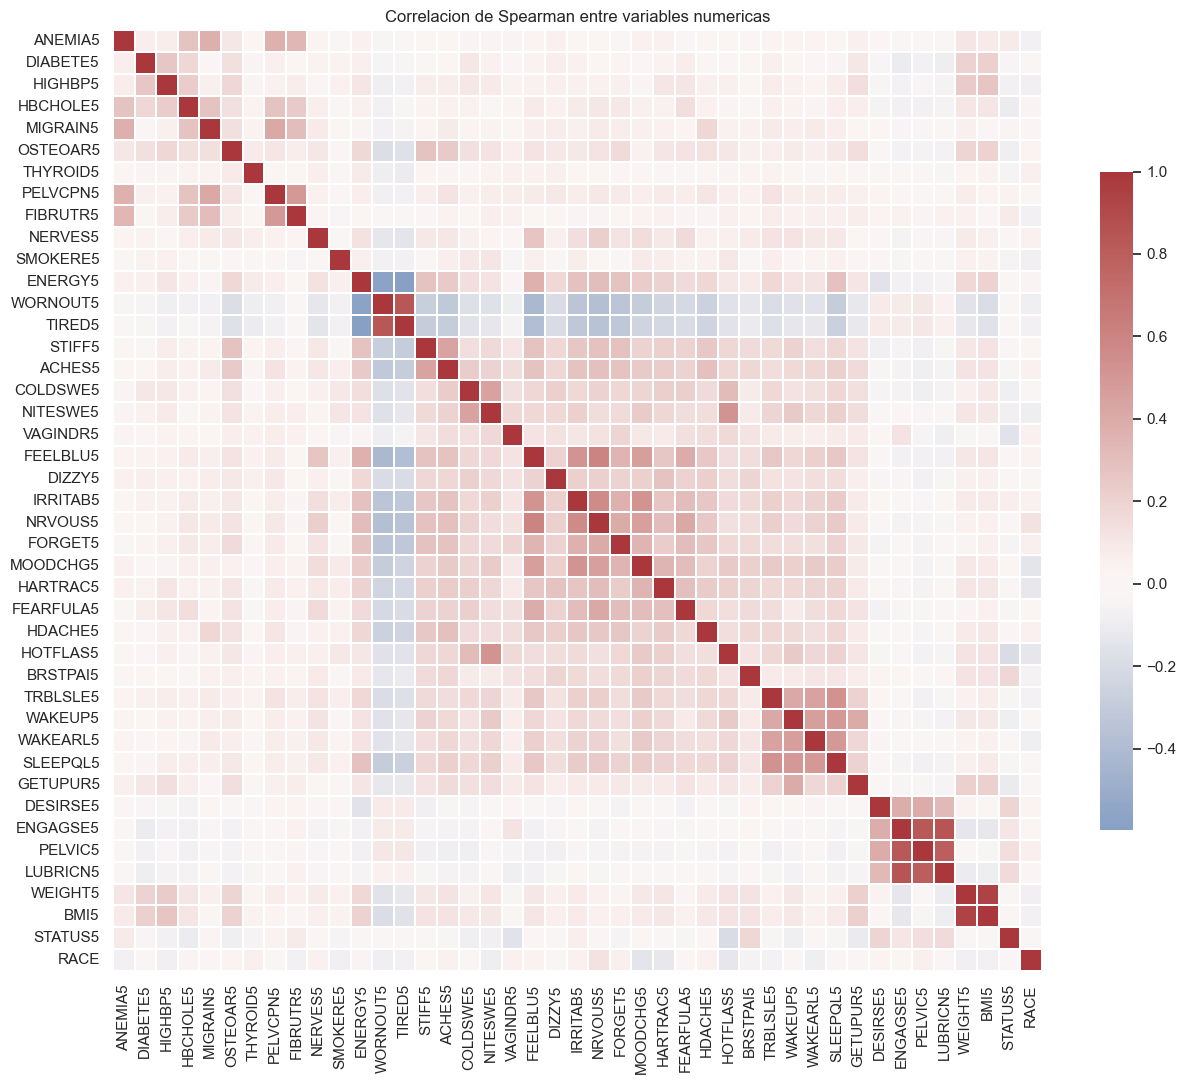

,variable_1,variable_2,abs_spearman
0,WEIGHT5,BMI5,0.943344
1,ENGAGSE5,LUBRICN5,0.844734
2,WORNOUT5,TIRED5,0.842274
3,ENGAGSE5,PELVIC5,0.828754
4,PELVIC5,LUBRICN5,0.797732
5,FEELBLU5,NRVOUS5,0.607000
6,ENERGY5,TIRED5,0.596409
7,ENERGY5,WORNOUT5,0.575835
8,IRRITAB5,NRVOUS5,0.568364
9,TRBLSLE5,SLEEPQL5,0.526386


In [13]:
corr = df[numeric_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.1, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation between numeric variables")
plt.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (
    upper.stack()
    .abs()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2", 0: "abs_spearman"})
)
display(high_corr.head(20))


## 9. Final Random Forest Feature Importance

This section does not train another exploratory model. To remain consistent with the real pipeline, it loads the feature importance generated by `train_model.py` from `outputs/metrics/random_forest_feature_importance_status5.csv`.

The importance values correspond to the final serialized Random Forest: median imputation, numeric variables in the same training order, `class_weight="balanced"`, and previously selected hyperparameters. `tipo_variable` is added only as clinical metadata for interpreting the ranking; it does not change the model importance calculation.

In [ ]:
feature_importance_path = METRICS_DIR / "random_forest_feature_importance_status5.csv"
shap_importance_path = METRICS_DIR / "shap_importance_top10.csv"

if not feature_importance_path.exists():
    raise FileNotFoundError(
        "Final model feature importance was not found. Run python train_model.py first."
    )

rf_importance = (
    pd.read_csv(feature_importance_path)
    .merge(variable_catalog[["variable", "tipo_variable", "descripcion"]], on="variable", how="left")
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

display(rf_importance.head(20))

fig, ax = plt.subplots(figsize=(8, 5.5))
top_rf = rf_importance.head(10).sort_values("importancia")
sns.barplot(data=top_rf, x="importancia", y="variable", color="#C44E52", ax=ax)
ax.set_title("Final Random Forest feature importance - Top 10")
ax.set_xlabel("Disminucion media de impureza")
ax.set_ylabel("Clinical variable")
plt.tight_layout()
plt.show()

if shap_importance_path.exists():
    shap_importance = pd.read_csv(shap_importance_path)
    importance_comparison = (
        rf_importance[["variable", "tipo_variable", "importancia"]]
        .merge(shap_importance, on="variable", how="outer")
        .sort_values(["mean_abs_shap", "importancia"], ascending=False, na_position="last")
    )
    print("Descriptive comparison between final Random Forest importance and global SHAP top 10:")
    display(importance_comparison.head(15))
else:
    print("SHAP top 10 is not available yet. Run python generate_figures.py to generate it.")

## SHAP Summary Plot: Top 10 with Colored Points

This cell generates the classic SHAP beeswarm for the 10 most relevant variables, with color defined by each variable value. In the multiclass setting, each record is plotted using the SHAP value associated with the class predicted by the Random Forest.


In [ ]:
import joblib
import shap
from sklearn.model_selection import StratifiedKFold

MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "random_forest_status5.joblib"
SHAP_SUMMARY_PATH = PROJECT_ROOT / "outputs" / "figures" / "shap_summary_top10.png"
TOP_N = 10

model = joblib.load(MODEL_PATH)
feature_names = list(model.feature_names_in_)
X = df.drop(columns=[TARGET]).loc[:, feature_names].apply(pd.to_numeric, errors="coerce")
y = df[TARGET].astype(int)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
_, valid_idx = list(cv.split(X, y))[-1]
X_valid = X.iloc[valid_idx].copy()

imputer = model.named_steps["imputer"]
classifier = model.named_steps["classifier"]
X_valid_imputed = pd.DataFrame(
    imputer.transform(X_valid),
    columns=feature_names,
    index=X_valid.index,
)

explainer = shap.TreeExplainer(classifier)
raw_shap_values = explainer.shap_values(X_valid_imputed)

if isinstance(raw_shap_values, list):
    shap_values = np.stack(raw_shap_values, axis=2)
else:
    shap_values = np.asarray(raw_shap_values)
    if shap_values.ndim == 2:
        shap_values = shap_values[:, :, np.newaxis]
    elif shap_values.shape[1] != len(feature_names) and shap_values.shape[2] == len(feature_names):
        shap_values = np.moveaxis(shap_values, 2, 1)

mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
top_idx = np.argsort(mean_abs_shap)[::-1][:TOP_N]
top_features = [feature_names[i] for i in top_idx]

predicted_labels = classifier.predict(X_valid_imputed)
class_to_index = {label: idx for idx, label in enumerate(classifier.classes_)}
predicted_class_idx = np.array([class_to_index[label] for label in predicted_labels])
row_idx = np.arange(shap_values.shape[0])
shap_predicted_class = shap_values[row_idx, :, predicted_class_idx]

plt.figure(figsize=(6.4, 4.8))
shap.summary_plot(
    shap_predicted_class[:, top_idx],
    X_valid_imputed.loc[:, top_features],
    feature_names=top_features,
    max_display=TOP_N,
    show=False,
    plot_size=None,
)
plt.title("SHAP summary plot - Top 10")
plt.xlabel("SHAP value for the predicted class")
plt.tight_layout()
SHAP_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SHAP_SUMMARY_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Figure saved to: {SHAP_SUMMARY_PATH}")


## SHAP Bar Plot by Class

For a cleaner manuscript figure, this cell generates an independent SHAP bar plot for each `STATUS5` class. Each plot summarizes the mean absolute magnitude of feature SHAP contributions for a specific class.


In [ ]:
SHAP_CLASS_NAMES = {
    2: "Natural post",
    3: "Late peri",
    4: "Early peri",
    5: "Pre",
}

for class_index, class_label in enumerate(classifier.classes_):
    class_explanation = shap.Explanation(
        values=shap_values[:, :, class_index],
        data=X_valid_imputed.values,
        feature_names=feature_names,
    )
    plt.figure(figsize=(6.0, 4.2))
    shap.plots.bar(class_explanation, max_display=TOP_N, show=False)
    plt.title(f"SHAP by class {class_label} - {SHAP_CLASS_NAMES.get(int(class_label), class_label)}")
    plt.xlabel("Valor SHAP absoluto medio")
    plt.tight_layout()
    class_path = PROJECT_ROOT / "outputs" / "figures" / f"shap_bar_class_{class_label}_top10.png"
    class_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(class_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure saved to: {class_path}")


## SHAP Beeswarm by Class

This cell generates an independent SHAP beeswarm for each `STATUS5` class. Unlike the global summary, each panel shows the direction and distribution of class-specific SHAP contributions.


In [ ]:
for class_index, class_label in enumerate(classifier.classes_):
    class_explanation = shap.Explanation(
        values=shap_values[:, :, class_index],
        data=X_valid_imputed.values,
        feature_names=feature_names,
    )
    plt.figure(figsize=(6.4, 4.8))
    shap.plots.beeswarm(class_explanation, max_display=TOP_N, show=False)
    plt.title(f"SHAP beeswarm class {class_label} - {SHAP_CLASS_NAMES.get(int(class_label), class_label)}")
    plt.xlabel("Valor SHAP")
    plt.tight_layout()
    class_path = PROJECT_ROOT / "outputs" / "figures" / f"shap_beeswarm_class_{class_label}_top10.png"
    class_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(class_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure saved to: {class_path}")


## 10. Automatic Findings to Guide Modeling


In [ ]:
dominant_values = []
for col in feature_cols:
    normalized_counts = df[col].value_counts(normalize=True, dropna=True)
    if not normalized_counts.empty:
        dominant_values.append(
            {
                "variable": col,
                "valor_dominante": normalized_counts.index[0],
                "proporcion": normalized_counts.iloc[0],
            }
        )

dominant_table = (
    pd.DataFrame(dominant_values)
    .query("proporcion >= 0.95")
    .merge(variable_catalog[["variable", "tipo_variable", "missing_pct"]], on="variable", how="left")
    .sort_values("proporcion", ascending=False)
)

summary = {
    "filas": len(df),
    "columns": df.shape[1],
    "target": TARGET,
    "clases_target": target_counts[TARGET].tolist(),
    "clase_mayoritaria_pct": float(target_counts["pct"].max()),
    "variables_con_nulos": int((df.isna().sum() > 0).sum()),
    "imputacion_modelo_final": "SimpleImputer(strategy='median') dentro del pipeline Random Forest",
    "variables_sin_metadatos": columns_without_metadata,
    "variables_metadatos_sin_datos": metadata_without_data,
    "top_exploratory_mutual_info": mi_table.head(10)["variable"].tolist(),
    "top_final_rf_importance": rf_importance.head(10)["variable"].tolist(),
    "dominant_variables_95pct": dominant_table["variable"].tolist(),
}

if "shap_importance" in globals():
    summary["top_final_global_shap"] = shap_importance.head(10)["variable"].tolist()

print("Resumen EDA")
for key, value in summary.items():
    print(f"- {key}: {value}")

print("\nVariables with dominant value >= 95%:")
display(dominant_table)

## 6.b Solapamiento vasomotor entre `STATUS5=3` y `STATUS5=4`

`HOTFLAS5`, `NITESWE5`, and `COLDSWE5` are compared between Late Perimenopause (`STATUS5=3`) and Early Perimenopause (`STATUS5=4`). The overlap percentage is calculated as the empirical overlap coefficient between ordinal distributions: the sum of the minimum observed proportions for each response value.


In [ ]:
vasomotor_vars = ["HOTFLAS5", "NITESWE5", "COLDSWE5"]
status_labels = {
    3: "Late Perimenopause",
    4: "Early Perimenopause",
}


def cliffs_delta_from_u(u_statistic: float, n_x: int, n_y: int) -> float:
    """Cliff's Delta orientado como grupo x menos grupo y."""
    if n_x == 0 or n_y == 0:
        return np.nan
    return (2 * u_statistic / (n_x * n_y)) - 1


def empirical_overlap_pct(x: pd.Series, y: pd.Series) -> float:
    """Porcentaje de solapamiento entre dos distribuciones discretas empiricas."""
    px = x.value_counts(normalize=True).sort_index()
    py = y.value_counts(normalize=True).sort_index()
    support = px.index.union(py.index)
    return 100 * np.minimum(px.reindex(support, fill_value=0), py.reindex(support, fill_value=0)).sum()


vasomotor_df = (
    df.loc[df[TARGET].isin(status_labels.keys()), [TARGET, *vasomotor_vars]]
    .assign(status_label=lambda data: data[TARGET].map(status_labels))
)

frequency_tables = {}
group_summary_rows = []
test_rows = []

for var in vasomotor_vars:
    valid = vasomotor_df[[TARGET, "status_label", var]].dropna().copy()
    valid[var] = pd.to_numeric(valid[var], errors="coerce")
    valid = valid.dropna(subset=[var])

    freq = (
        valid.groupby([TARGET, "status_label", var])
        .size()
        .reset_index(name="n")
        .sort_values([TARGET, var])
    )
    freq["pct_grupo"] = 100 * freq["n"] / freq.groupby(TARGET)["n"].transform("sum")
    frequency_tables[var] = freq

    group_3 = valid.loc[valid[TARGET].eq(3), var]
    group_4 = valid.loc[valid[TARGET].eq(4), var]
    u_stat, p_value = mannwhitneyu(group_3, group_4, alternative="two-sided")
    test_rows.append(
        {
            "variable": var,
            "grupo_referencia": "Late Perimenopause (STATUS5=3)",
            "grupo_comparacion": "Early Perimenopause (STATUS5=4)",
            "mann_whitney_u": u_stat,
            "p_value": p_value,
            "cliffs_delta": cliffs_delta_from_u(u_stat, len(group_3), len(group_4)),
            "overlap_pct": empirical_overlap_pct(group_3, group_4),
        }
    )

    for status_value, group_values in valid.groupby(TARGET)[var]:
        q1, median, q3 = group_values.quantile([0.25, 0.50, 0.75])
        group_summary_rows.append(
            {
                "variable": var,
                TARGET: status_value,
                "category": status_labels[int(status_value)],
                "n": int(group_values.size),
                "mediana": median,
                "q1": q1,
                "q3": q3,
                "iqr": q3 - q1,
            }
        )

for var, freq in frequency_tables.items():
    print(f"Frequencies for {var}")
    display(freq)

vasomotor_group_summary = pd.DataFrame(group_summary_rows)
vasomotor_test_summary = pd.DataFrame(test_rows)
display(vasomotor_group_summary)
display(vasomotor_test_summary)

plot_df = vasomotor_df.melt(
    id_vars=[TARGET, "status_label"],
    value_vars=vasomotor_vars,
    var_name="variable",
    value_name="valor",
).dropna(subset=["valor"])
plot_df["valor"] = pd.to_numeric(plot_df["valor"], errors="coerce")
plot_df = plot_df.dropna(subset=["valor"])

fig, axes = plt.subplots(nrows=len(vasomotor_vars), ncols=2, figsize=(12, 12), sharey="row")
for row, var in enumerate(vasomotor_vars):
    subset = plot_df[plot_df["variable"].eq(var)]
    sns.violinplot(
        data=subset,
        x="status_label",
        y="valor",
        hue="status_label",
        inner="quartile",
        cut=0,
        legend=False,
        ax=axes[row, 0],
    )
    axes[row, 0].set_title(f"{var}: violin plot")
    axes[row, 0].set_xlabel("")
    axes[row, 0].set_ylabel("Valor")
    axes[row, 0].tick_params(axis="x", rotation=20)

    sns.boxplot(
        data=subset,
        x="status_label",
        y="valor",
        hue="status_label",
        legend=False,
        ax=axes[row, 1],
    )
    axes[row, 1].set_title(f"{var}: boxplot")
    axes[row, 1].set_xlabel("")
    axes[row, 1].set_ylabel("")
    axes[row, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
